In [30]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [24]:
df = pd.read_csv('./models/BFreqRatios.csv', skiprows=2,
                 usecols=[0, 1, 2], names=['freq', 'Rb87', 'Rb85'])

freq = df['freq'].values
Rb87 = df['Rb87'].values
Rb85 = df['Rb85'].values

# print(freq)
# print(Rb87)
# print(Rb85)


m87, b87 = np.polyfit(freq, Rb87, deg=1)
m85, b85 = np.polyfit(freq, Rb85, deg=1)

xFit = np.linspace(min(freq),max(freq), num=200)
Rb87Fit = m87 * xFit + b87
Rb85Fit = m85 * xFit + b85

print(m85/m87)

1.5011150047814381


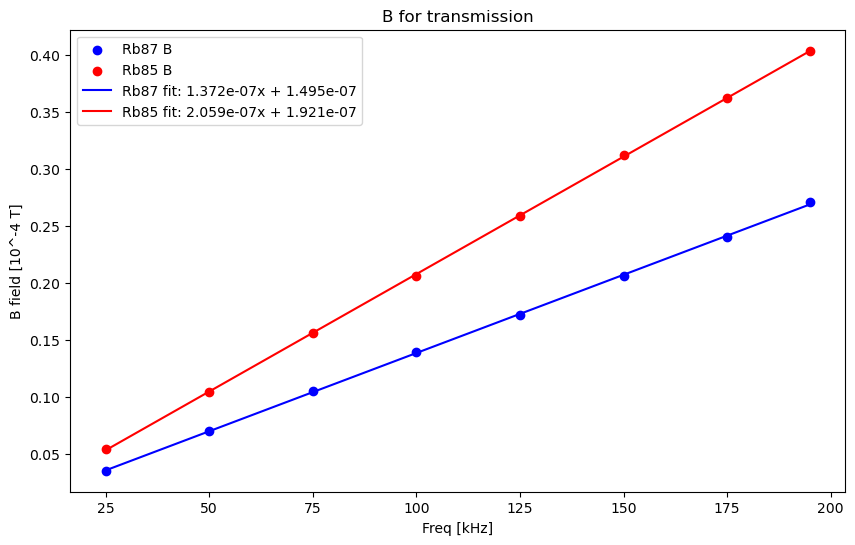

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(freq, Rb87 * 10**4, label='Rb87 B', color='blue')
plt.scatter(freq, Rb85 * 10**4, label='Rb85 B', color='red')

plt.plot(xFit, Rb87Fit * 10**4, label=f'Rb87 fit: {m87:.3e}x + {b87:.3e}', color='blue')
plt.plot(xFit, Rb85Fit * 10**4, label=f'Rb85 fit: {m85:.3e}x + {b85:.3e}', color='red')

# Labels and formatting
plt.xlabel('Freq [kHz]')
plt.ylabel('B field [10^-4 T]')
plt.title('B for transmission')
plt.legend()
plt.savefig("./figures/gfactor linear range Mar9", dpi=300)

plt.show()

In [27]:
df = pd.read_csv('./models/BFreqRatiosUncertain.csv', skiprows=2,
                 usecols=[0,2,3,4,5], names=['freq', 'Rb87', 'uRb87', 'Rb85', 'uRb85'])

freq = df['freq'].values
Rb87 = df['Rb87'].values
Rb85 = df['Rb85'].values
uRb87 = df['uRb87'].values
uRb85 = df['uRb85'].values

In [34]:
def linear_func(x, m, b):
    return m * x + b

popt, pcov = curve_fit(linear_func, freq, Rb87, sigma=uRb87, absolute_sigma=True)
perr87 = np.sqrt(np.diag(pcov))
m87 = ufloat(popt[0], perr87[0])
b87 = ufloat(popt[1], perr87[1])

popt, pcov = curve_fit(linear_func, freq, Rb85, sigma=uRb85, absolute_sigma=True)
perr85 = np.sqrt(np.diag(pcov))
m85 = ufloat(popt[0], perr87[0])
b85 = ufloat(popt[1], perr87[1])

xFit = np.linspace(min(freq),max(freq), num=200)
Rb87Fit = m87.nominal_value * xFit + b87.nominal_value
Rb85Fit = m85.nominal_value * xFit + b85.nominal_value

slopeRatio = m85/m87

print(f"Slope ratio: {slopeRatio:.3e}")

Slope ratio: (1.514+/-0.028)e+00


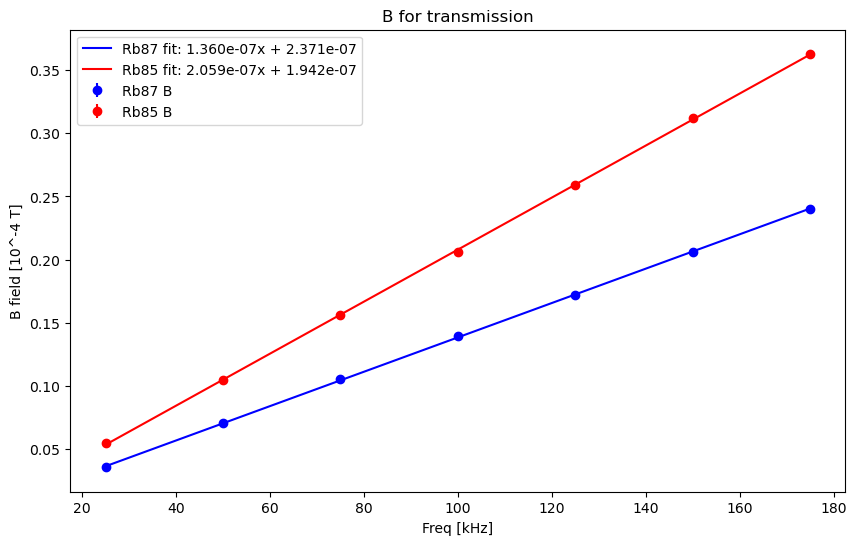

In [44]:
plt.figure(figsize=(10, 6))
plt.errorbar(freq, Rb87 * 10**4, yerr=uRb87 * 10**4, label='Rb87 B', fmt='o', color='blue')
plt.errorbar(freq, Rb85 * 10**4, yerr=uRb85 * 10**4, label='Rb85 B', fmt='o', color='red')

plt.plot(xFit, Rb87Fit * 10**4, label=f'Rb87 fit: {m87.nominal_value:.3e}x + {b87.nominal_value:.3e}', color='blue')
plt.plot(xFit, Rb85Fit * 10**4, label=f'Rb85 fit: {m85.nominal_value:.3e}x + {b85.nominal_value:.3e}', color='red')

# Labels and formatting
plt.xlabel('Freq [kHz]')
plt.ylabel('B field [10^-4 T]')
plt.title('B for transmission')
plt.legend()
plt.savefig("./figures/gfactor linear range Mar 9", dpi=300)

plt.show()